# Практическое занятие №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

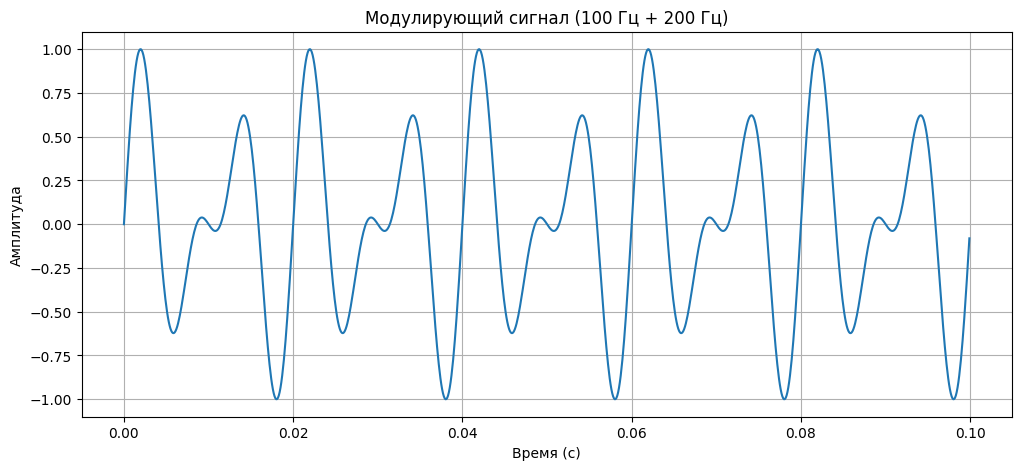

In [166]:
fm1 = 100
fm2 = 150
m_t = [] # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]
m_t = np.sin(2*np.pi*fm1*t) + 0.8*np.sin(2*np.pi*fm2*t)

m_t = m_t / np.max(np.abs(m_t)) #нормализация

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [167]:
a_am = 0.2
s_am = []
s_am = Ac*(1+a_am*m_t)*np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [168]:
beta_pm = 5
s_pm = []
s_pm = Ac*np.cos(2*np.pi*fc*t+beta_pm*m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

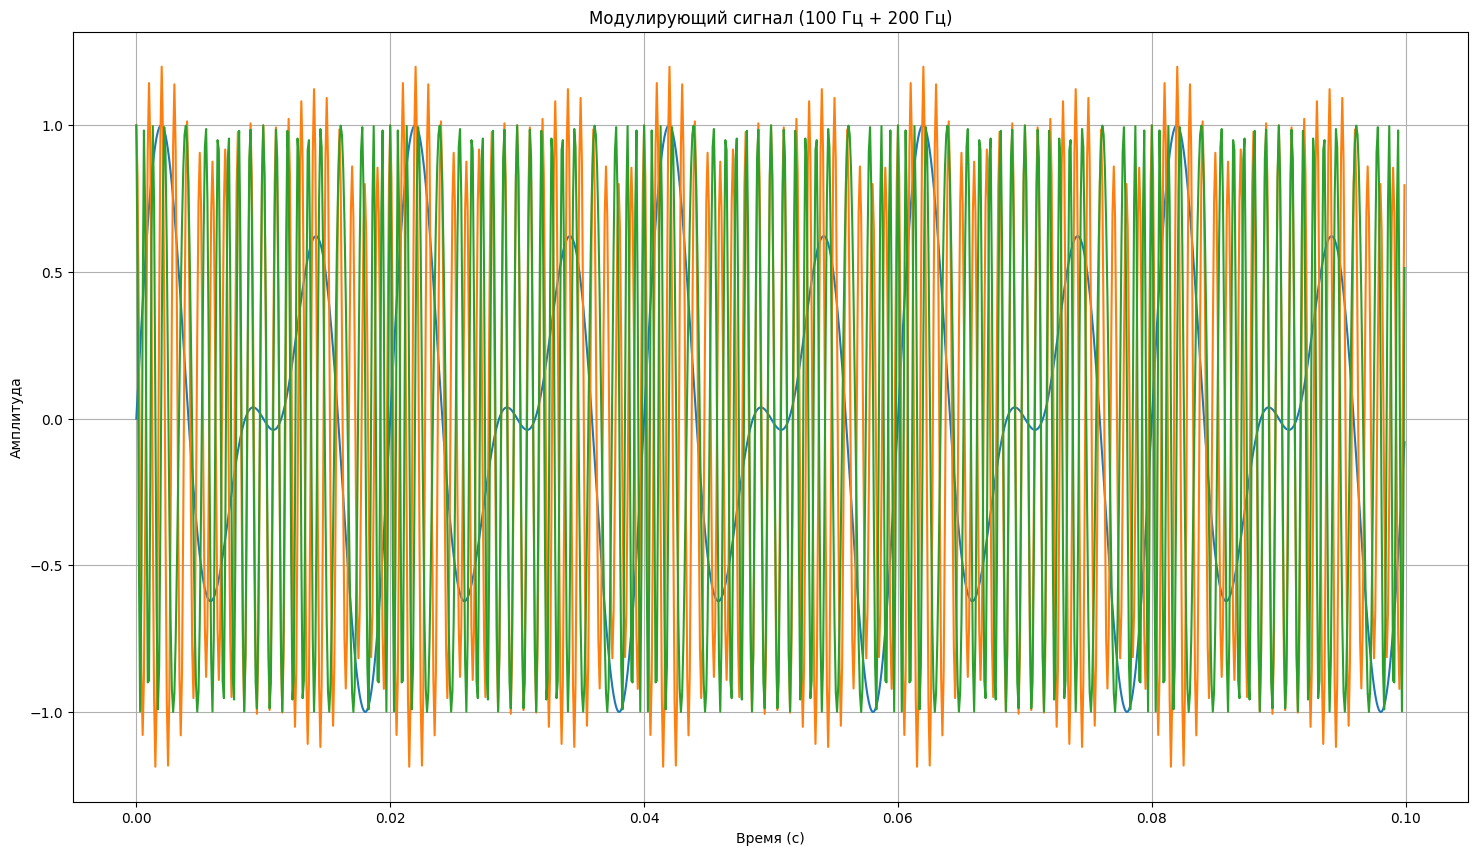

In [169]:
plt.figure(figsize=(18,10))
plt.plot(t, m_t)
plt.plot(t, s_am)
plt.plot(t, s_pm)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')


plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.grid(True)
plt.show()


Так как плохо видно на одном графике, сделаю на нескольких

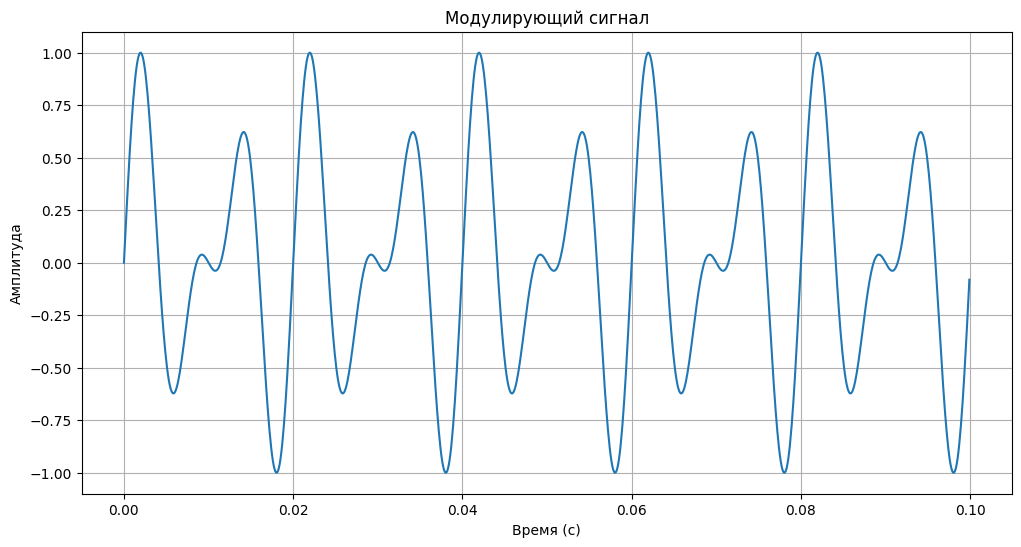

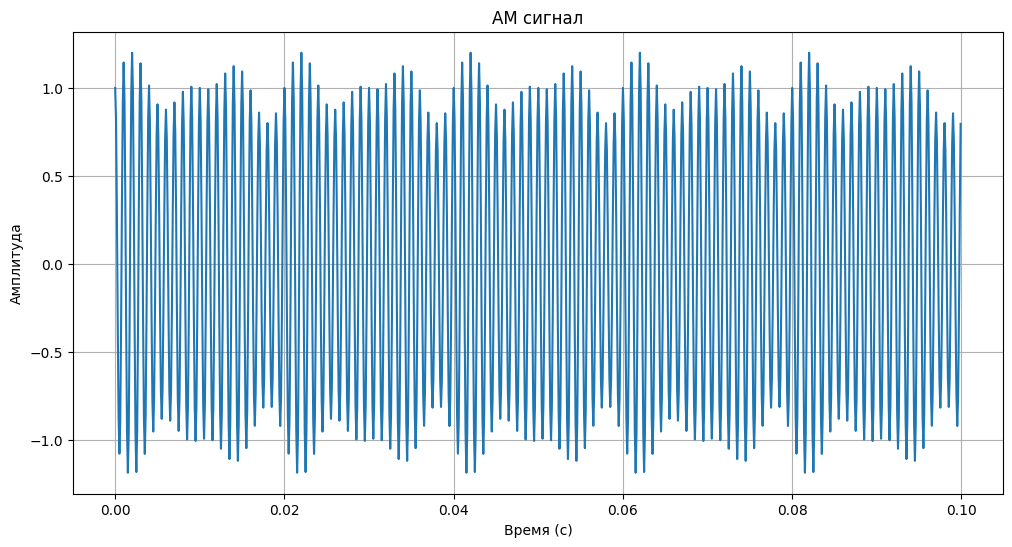

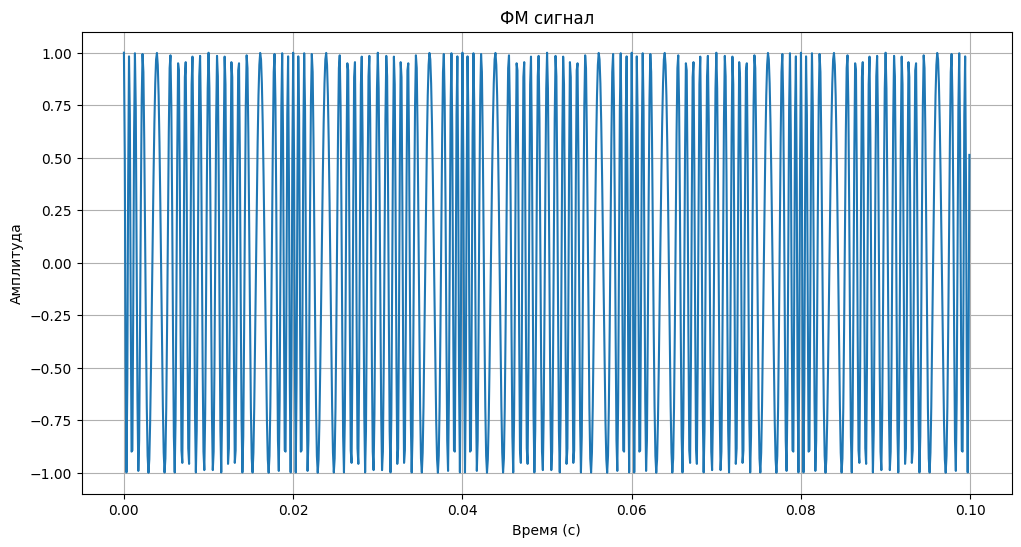

In [170]:
plt.figure(figsize=(12,6))
plt.plot(t, m_t)
plt.title('Модулирующий сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(t, s_am)
plt.title('АМ сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(t, s_pm)
plt.title('ФМ сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [171]:
def plot_spectrum(s, fs, title):
    N = len(s)
    spec = np.fft.rfft(s) / N
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(spec)*2
    amp[0] /= 2
    plt.figure()
    plt.stem(freq, amp)
    plt.xlim(0, 2000)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.show()

### 2.2. Спектр АМ

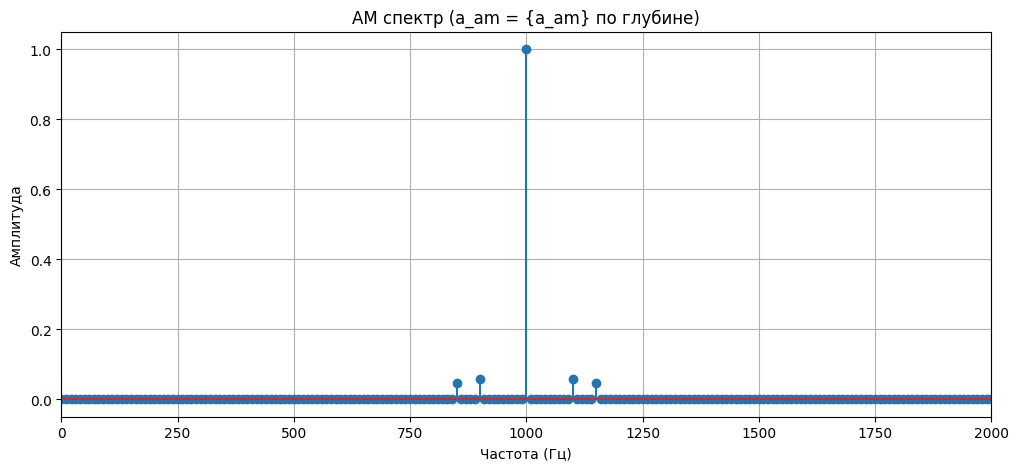

In [172]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

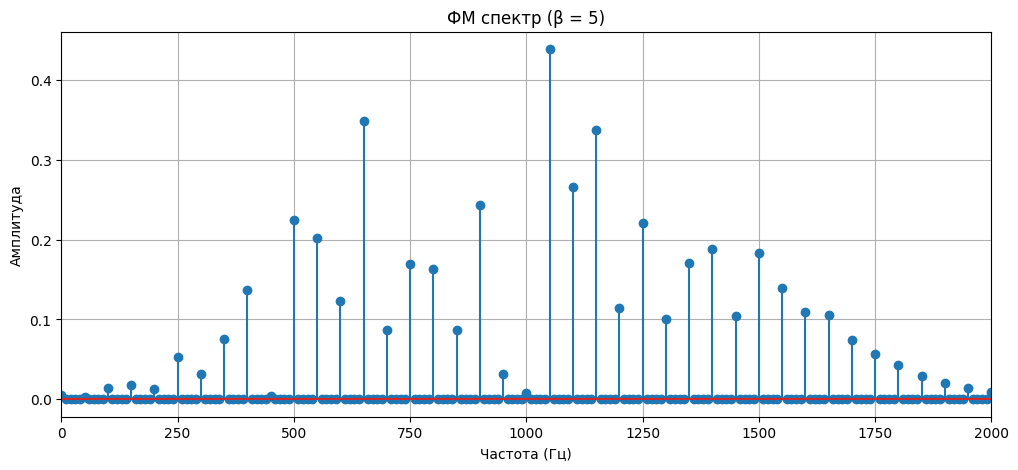

In [173]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

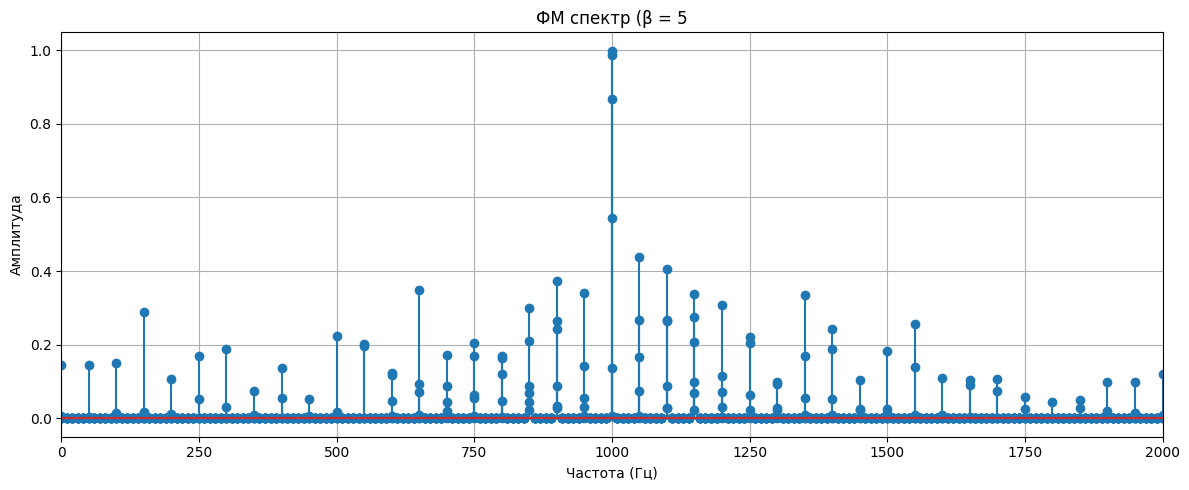

In [174]:
b = [0.1, 0.3, 1, 2, 5, 10]
for beta in b:
    s_pm_test = Ac * np.cos(2*np.pi*fc*t + beta * m_t)
    N = len(s_pm_test)
    spec = np.fft.rfft(s_pm_test) / N
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(spec) * 2
    amp[0] /= 2

    plt.stem(freq, amp)
    plt.xlim(0, 2000)
    plt.title(f'ФМ спектр (β = {beta_pm}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
plt.tight_layout()
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [175]:
def pm_spectrum(beta=5):
    s_pm = Ac * np.cos(2*np.pi*fc*t + beta * m_t)
    N = len(s_pm)
    spec = np.fft.rfft(s_pm) / N
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(spec) * 2
    amp[0] /= 2
    plt.figure()
    plt.stem(freq, amp)
    plt.xlim(0, 2000)
    plt.title(f'ФМ спектр (β = {beta})')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.show()

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

{Спектр АМ содержит только 5 компонент, потому что сигнал представляет собой сумму двух синусоид 150 Гц и 100 Гц. А в спектре есть основная линия самая длинная в центре на отметке в 1000 Гц и по две линии на каждую из синусоид 100 Гц и 150 Гц
При малых бета спектр ФМ выглядит аналогично спектру АМ
При увеличении беты амплитуда уменьшается, число компонент растет и спектр расширяется}

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

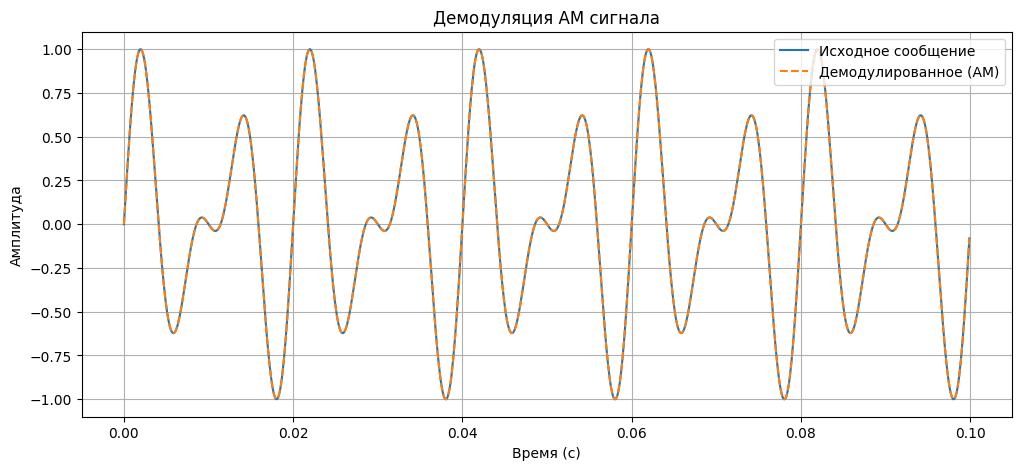

In [176]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [177]:
print(np.std(m_t - demod_am))

8.080484916484441e-14


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

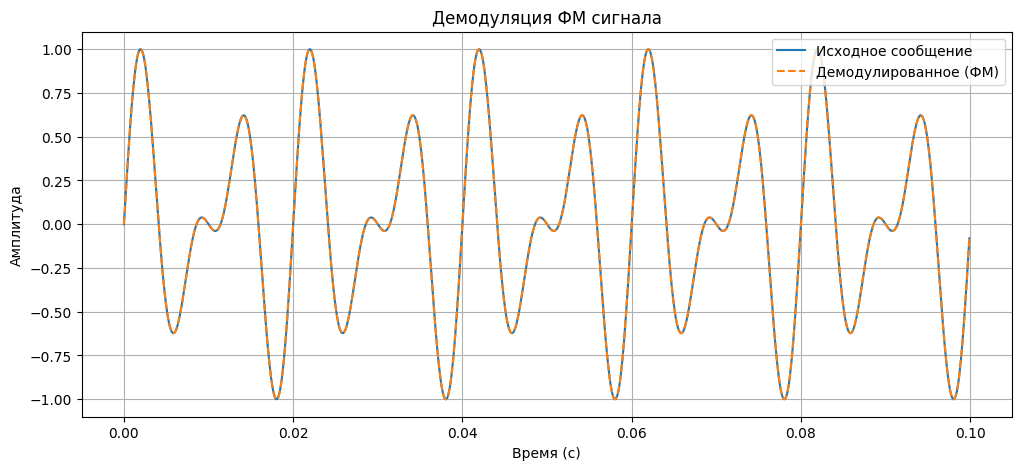

In [178]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

{np.unwrap важно использовать, потому что могут возникнуть скачки на значениях 2pi, которые np.unwrap нивелирует и восстанавливает непрерывность}

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [179]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-04-13 11:35:36--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-04-13 11:35:36--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.04s   

2026-04-13 11:35:36 (14.6 MB/s) - ‘audio.wav’ saved [563756/563756]



In [180]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

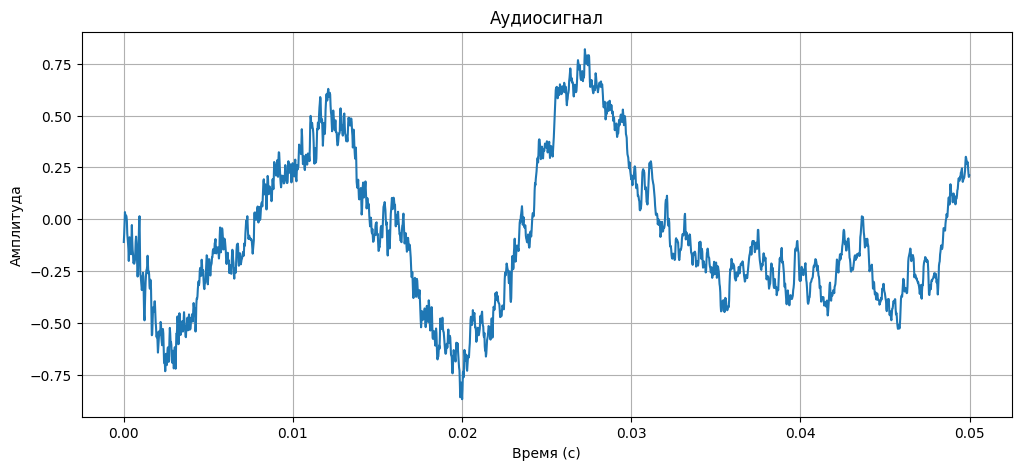

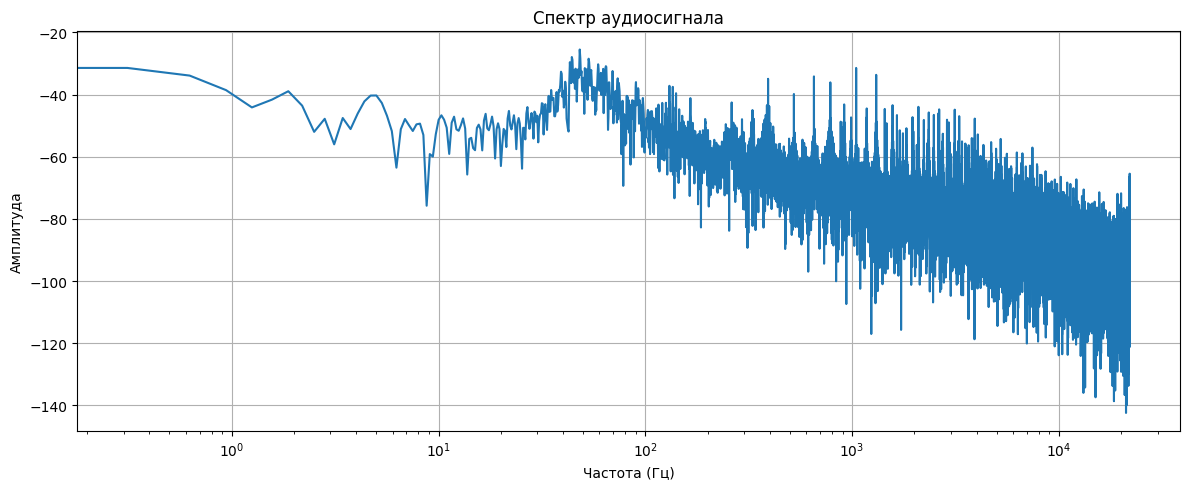

In [181]:
plt.plot(t_audio[:int(0.05*fs_audio)], melody[:int(0.05*fs_audio)])
plt.title('Аудиосигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

N = len(melody)
spec_audio = np.fft.rfft(melody) / N
freq_audio = np.fft.rfftfreq(N, d=1/fs_audio)
amp_audio = np.abs(spec_audio) * 2
amp_audio[0] /= 2
plt.semilogx(freq_audio, 20*np.log10(amp_audio + 1e-10))
plt.title('Спектр аудиосигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

{Заметные пики наблюдаются до 6 * 10^3 Гц. Несущей можно выбрать частоту около 15 кГц, чтобы не перекрывать области низких частот. Для ФМ нужна частота чуть больше в районе 20 кГц, чтобы избежать наложения на низкие частоты}

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [182]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [183]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [184]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [185]:
analytic_am_audio = hilbert(s_am_audio)
envelope_am_audio = np.abs(analytic_am_audio)
demod_am_audio = (envelope_am_audio - 1) / a_am #если делить на (a_am - 1), звук почти не слышно
demod_am_audio = demod_am_audio[100:-100]
display(Audio(demod_am_audio, rate=fs_audio))

Демодулируйте зашумлёный АМ-сигнал.

In [186]:
analytic_am_noisy = hilbert(s_am_noisy)
envelope_am_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = envelope_am_noisy / (a_am-1)
demod_am_noisy = demod_am_noisy[100:-100]
display(Audio(demod_am_noisy, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

{Качество звука изменилось. При добавлении шума качество ухудшилось.
Чем ниже амплитуда, тем меньше разница. При 0.2 хорошо слышен шум, а при 0.5+ слышен в большей степени шум. При 0.01 шума почти нет, при 0.01-0.3 шум становится сильнее, но не заглушает мелодию, при 0.3-1 шум заглушает мелодию}

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [187]:
analytic_pm_audio = hilbert(s_pm_audio)
phase_pm_audio = np.unwrap(np.angle(analytic_pm_audio))
phase_no_carrier_pm = phase_pm_audio - 2 * np.pi * fc_high * t_audio
demod_pm_audio = phase_no_carrier_pm - np.mean(phase_no_carrier_pm)
demod_pm_audio = demod_pm_audio / beta_pm_audio
demod_pm_audio = demod_pm_audio[100:-100]
display(Audio(demod_pm_audio, rate=fs_audio))

Демодулируйте зашумлёный ФМ-сигнал.

In [188]:
analytic_pm_noisy = hilbert(s_pm_noisy)
phase_pm_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_pm_noisy = phase_pm_noisy - 2 * np.pi * fc_high * t_audio
demod_pm_noisy = phase_no_carrier_pm_noisy - np.mean(phase_no_carrier_pm_noisy)
demod_pm_noisy = demod_pm_noisy / beta_pm_audio
demod_pm_noisy = demod_pm_noisy[100:-100]
display(Audio(demod_pm_noisy, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

{Качество ухудшилось.
Заметная разница появляется при амплитуде шума от 0,2. При 0,1 шум ещё слабо заметен, а при 0,2 уже хорошо слышен, при 0,5 и выше мелодия сильно заглушается.
Искажения растут с увеличением бета. При 0,5 шума почти нет, при 2 он есть, но мелодия разборчива, при 5 сильный шум.}

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

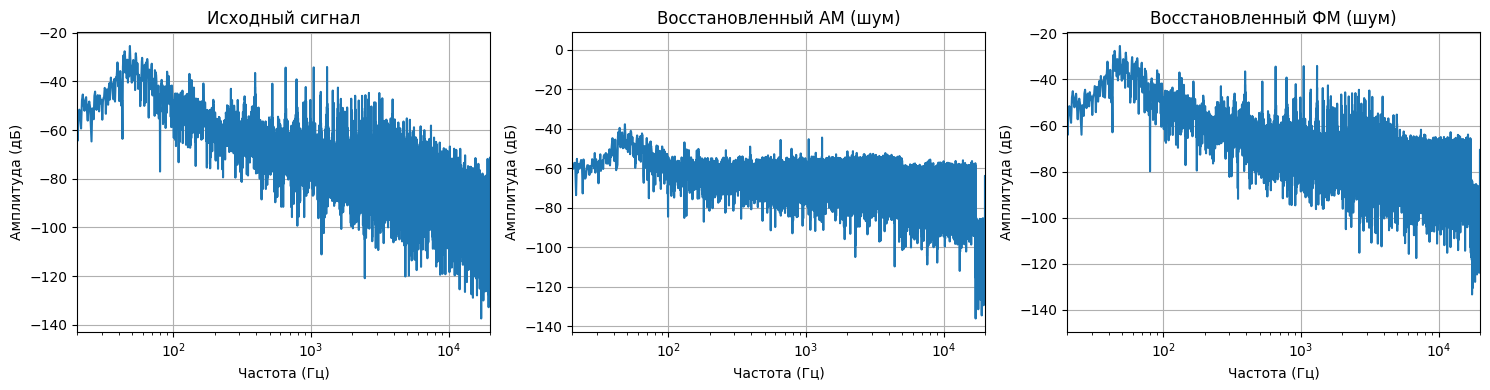

In [189]:
def plot_spectrum_audio(s, fs, title, ax):
    N = len(s)
    spec = np.fft.rfft(s) / N
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = np.abs(spec) * 2
    amp[0] /= 2
    ax.semilogx(freq, 20*np.log10(amp + 1e-10))
    ax.set_title(title)
    ax.set_xlabel('Частота (Гц)')
    ax.set_ylabel('Амплитуда (дБ)')
    ax.grid(True)
    ax.set_xlim(20, 20000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_spectrum_audio(melody_trimmed, fs_audio, 'Исходный сигнал', axes[0])
plot_spectrum_audio(demod_am_noisy, fs_audio, 'Восстановленный АМ (шум)', axes[1])
plot_spectrum_audio(demod_pm_noisy, fs_audio, 'Восстановленный ФМ (шум)', axes[2])
plt.tight_layout()
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

{Визуально искажения спектра заметны. В АМ появляются дополнительный шум во всём диапазоне, особенно для низких частот. Для ФМ спектр искажён меньше, однако также виден повышенный уровень шума}

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

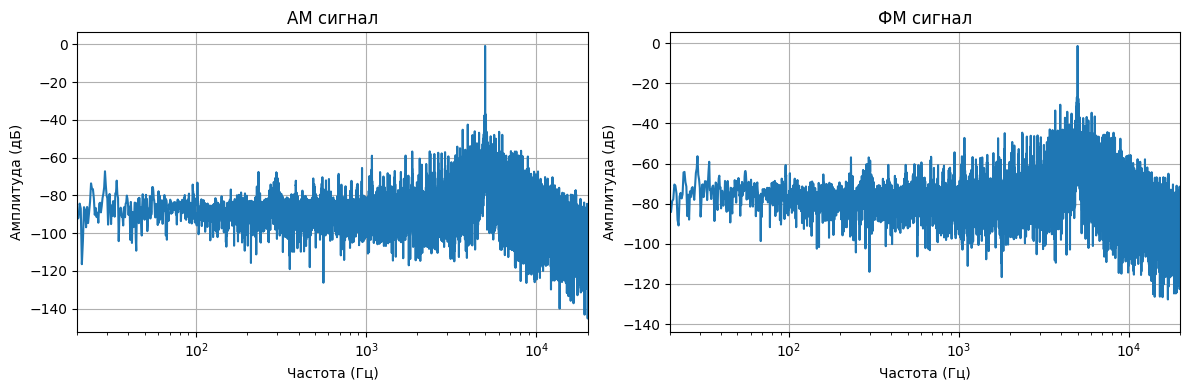

In [190]:
a_am_comp = 0.5
s_am_audio_comp = Ac * (1 + a_am_comp * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_audio_comp = Ac * np.cos(2 * np.pi * fc_high * t_audio + 2 * melody)   # beta=2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_spectrum_audio(s_am_audio_comp, fs_audio, 'АМ сигнал', axes[0])
plot_spectrum_audio(s_pm_audio_comp, fs_audio, 'ФМ сигнал', axes[1])
plt.tight_layout()
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

{При a_am=0.5 и β=2 заметные искажения АМ начинаются уже при амплитуде шума 0.05, а ФМ уже при амплитуде около 0.2. Вывод: ФМ значительно устойчивее к амплитудным помехам, и лучше использовать ФМ.}